# Notebook 1: Pair Screening & Diagnostics

**Steps covered:**
1. Download sector universe (XLF financials + XLE energy, 2010–2024)
2. Screen for cointegrated pairs (Engle-Granger)
3. ADF test on spreads
4. Ornstein-Uhlenbeck parameter fitting
5. Kalman filter demo — dynamic hedge ratio visualization

**Key differentiator:** Kalman filter hedge ratio adapts continuously vs static OLS, which assumes a constant relationship over the full period.

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from statarb.data import download_prices, SECTOR_BUCKETS, EXTENDED_BUCKETS
from statarb.cointegration import find_cointegrated_pairs, adf_test, compute_ols_spread
from statarb.ou_process import fit_ou_process
from statarb.kalman import KalmanHedgeRatio, kalman_spread, calibrate_R
from statarb.signals import compute_zscore_kalman

sns.set_theme(style='darkgrid', palette='husl')
plt.rcParams['figure.figsize'] = (14, 5)
print('Setup complete')

Setup complete


## 1. Download Universe

In [2]:
START, END = '2010-01-01', '2024-12-31'

all_tickers = list(set(
    EXTENDED_BUCKETS['financials'] + EXTENDED_BUCKETS['energy'] + EXTENDED_BUCKETS['commodity_etf']
))
print(f'Universe: {len(all_tickers)} tickers')
print(f'  Financials (XLF): {EXTENDED_BUCKETS["financials"]}')
print(f'  Energy (XLE):     {EXTENDED_BUCKETS["energy"]}')
print(f'  Commodity ETFs:   {EXTENDED_BUCKETS["commodity_etf"]}  (Chan canonical pair)')

log_prices = download_prices(all_tickers, start=START, end=END)
print(f'\nLoaded: {log_prices.shape[0]} trading days x {log_prices.shape[1]} tickers')
print(f'Date range: {log_prices.index[0].date()} to {log_prices.index[-1].date()}')
log_prices.tail(3)

Universe: 16 tickers
  Financials (XLF): ['JPM', 'BAC', 'WFC', 'GS', 'MS', 'C', 'BK', 'STT']
  Energy (XLE):     ['XOM', 'CVX', 'COP', 'EOG', 'SLB', 'PSX']
  Commodity ETFs:   ['EWA', 'EWC']  (Chan canonical pair)

Loaded: 3773 trading days x 15 tickers
Date range: 2010-01-04 to 2024-12-30


Ticker,BAC,BK,C,COP,CVX,EOG,EWA,EWC,GS,JPM,MS,SLB,STT,WFC,XOM
Date,,,,,,,,,,,,,,,
2024-12-26,3.768078,4.330900,4.230314,4.524412,4.905508,4.739683,3.159152,3.683765,6.339695,5.463084,4.813791,3.593408,4.556831,4.241226,4.618599
2024-12-27,3.763353,4.320894,4.225396,4.524721,4.905646,4.739600,3.148404,3.678804,6.330968,5.454949,4.803822,3.595261,4.546939,4.232127,4.618505
2024-12-30,3.753608,4.314947,4.216768,4.526474,4.899167,4.741094,3.144656,3.675567,6.326393,5.447248,4.795822,3.595526,4.543891,4.222234,4.611721


## 2. Cointegration Screening

In [3]:
pairs = find_cointegrated_pairs(log_prices, significance=0.10, buckets=EXTENDED_BUCKETS)

print(f'Cointegrated pairs at p < 0.10: {len(pairs)}')
pairs_df = pd.DataFrame([
    {
        'pair': f"{p['pair'][0]}/{p['pair'][1]}",
        'bucket': p['bucket'],
        'p_value': round(p['p_value'], 5),
        't_stat': round(p['t_stat'], 4),
        'n_obs': p['n_obs'],
    }
    for p in pairs
])
pairs_df

Cointegrated pairs at p < 0.10: 5


,pair,bucket,p_value,t_stat,n_obs
0,C/BK,financials,0.02476,-3.5963,3773
1,C/STT,financials,0.06033,-3.2608,3773
2,EWA/EWC,commodity_etf,0.06169,-3.2518,3773
3,BAC/C,financials,0.08844,-3.0993,3773
4,GS/MS,financials,0.09571,-3.0642,3773


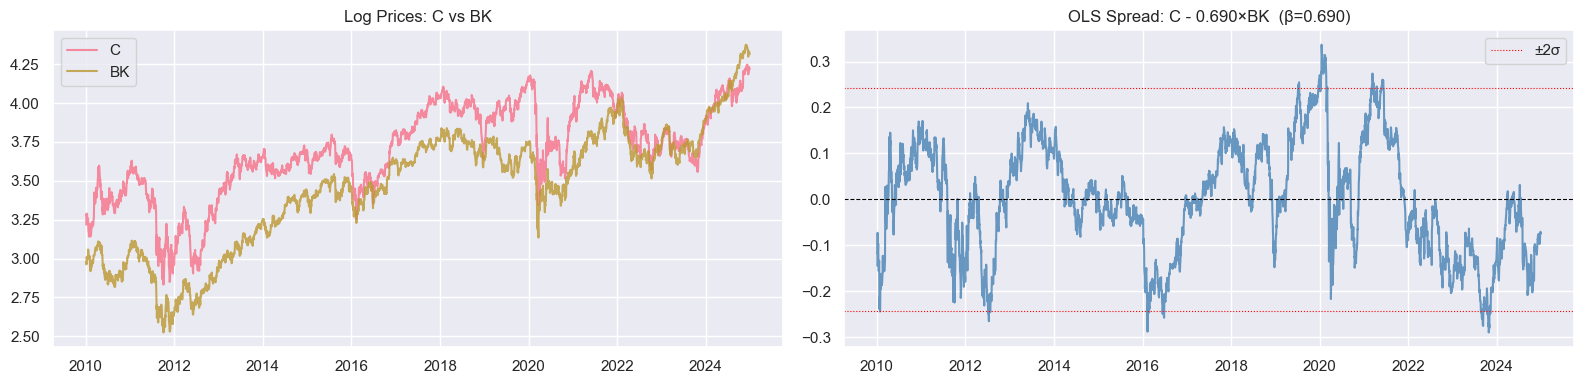

In [4]:
# Visualize price series for top pair
if pairs:
    t1, t2 = pairs[0]['pair']
    fig, axes = plt.subplots(1, 2, figsize=(16, 4))
    
    axes[0].plot(log_prices[t1], label=t1, alpha=0.8)
    axes[0].plot(log_prices[t2], label=t2, alpha=0.8)
    axes[0].set_title(f'Log Prices: {t1} vs {t2}')
    axes[0].legend()
    axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    
    # OLS spread
    spread_ols, beta_ols, alpha_ols = compute_ols_spread(log_prices[t1], log_prices[t2])
    axes[1].plot(spread_ols, color='steelblue', alpha=0.8)
    axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
    axes[1].axhline(spread_ols.mean() + 2*spread_ols.std(), color='red', linewidth=0.8, linestyle=':', label='±2σ')
    axes[1].axhline(spread_ols.mean() - 2*spread_ols.std(), color='red', linewidth=0.8, linestyle=':')
    axes[1].set_title(f'OLS Spread: {t1} - {beta_ols:.3f}×{t2}  (β={beta_ols:.3f})')
    axes[1].legend()
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    
    plt.tight_layout()
    plt.show()

## 3. ADF Stationarity Test on Spread

In [5]:
if pairs:
    t1, t2 = pairs[0]['pair']
    spread_ols, _, _ = compute_ols_spread(log_prices[t1], log_prices[t2])
    
    adf = adf_test(spread_ols, name=f'{t1}/{t2} OLS Spread')
    print(f"ADF Test: {adf['name']}")
    print(f"  Statistic:    {adf['adf_statistic']:.4f}")
    print(f"  p-value:      {adf['p_value']:.4f}")
    print(f"  Stationary:   {'YES ✓' if adf['stationary_5pct'] else 'NO ✗'}")
    print(f"  Critical values: {adf['critical_values']}")

ADF Test: C/BK OLS Spread
  Statistic:    -3.5960
  p-value:      0.0058
  Stationary:   YES ✓
  Critical values: {'1%': np.float64(-3.432088051536941), '5%': np.float64(-2.862307975403198), '10%': np.float64(-2.5671788037403287)}


## 4. Ornstein-Uhlenbeck Process Fitting

The OU process characterizes mean-reversion speed. The **half-life** tells us how many days it takes for a divergence to decay by half — the key parameter for position sizing and holding period expectations.

OU Parameters (formation window: 2010-01-04 → 2017-06-29)
  kappa (mean-reversion speed): 0.0101
  mu    (long-run mean):         -0.0011
  sigma (diffusion):             0.0148
  sigma_eq (stationary std):     0.1040
  Half-life:                     68.6 trading days


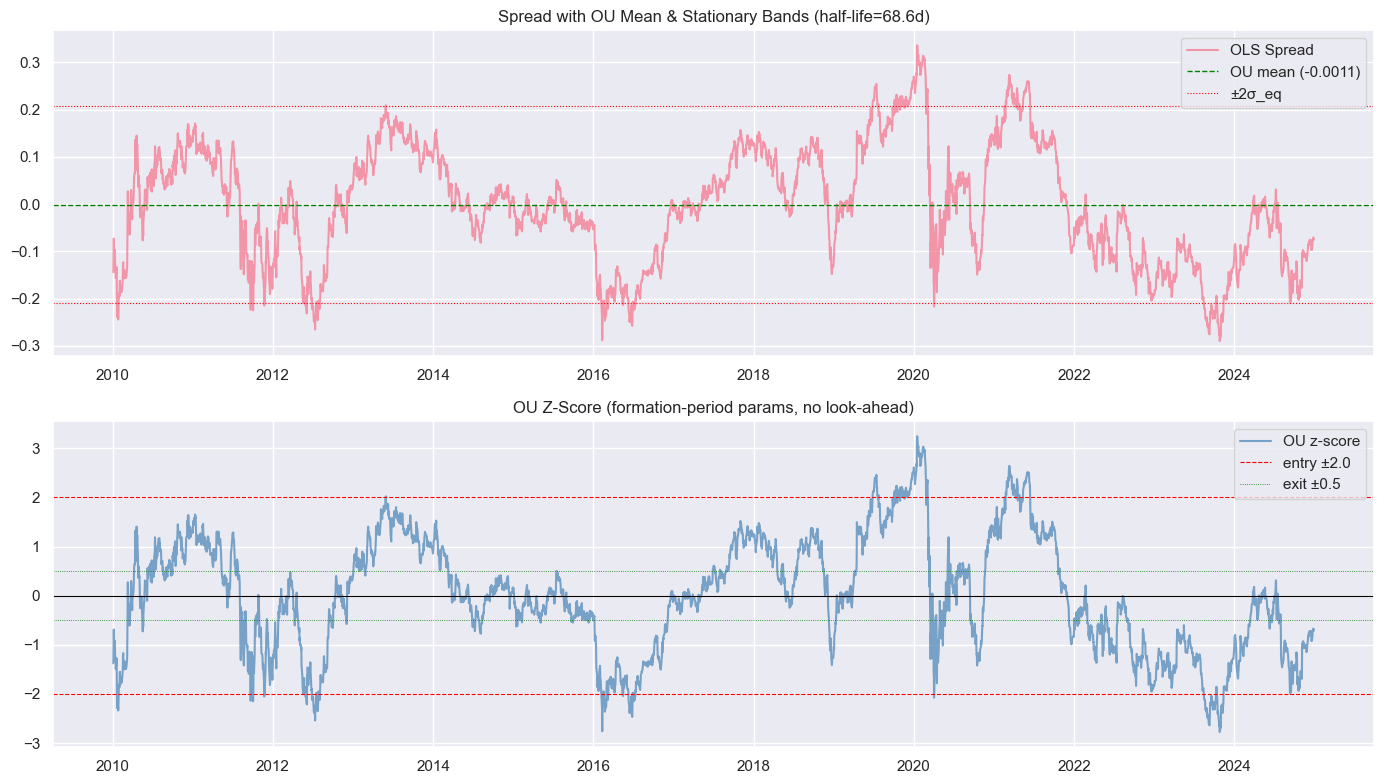

In [6]:
if pairs:
    t1, t2 = pairs[0]['pair']
    spread_ols, _, _ = compute_ols_spread(log_prices[t1], log_prices[t2])
    
    # Fit OU on first 50% (formation window)
    n = len(spread_ols)
    split = n // 2
    ou = fit_ou_process(spread_ols.iloc[:split])
    
    print(f'OU Parameters (formation window: {spread_ols.index[0].date()} → {spread_ols.index[split-1].date()})')
    print(f'  kappa (mean-reversion speed): {ou.kappa:.4f}')
    print(f'  mu    (long-run mean):         {ou.mu:.4f}')
    print(f'  sigma (diffusion):             {ou.sigma:.4f}')
    print(f'  sigma_eq (stationary std):     {ou.sigma_eq:.4f}')
    print(f'  Half-life:                     {ou.half_life:.1f} trading days')
    
    # OU z-score
    z_ou = (spread_ols - ou.mu) / ou.sigma_eq
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    
    axes[0].plot(spread_ols, label='OLS Spread', alpha=0.7)
    axes[0].axhline(ou.mu, color='green', linewidth=1, linestyle='--', label=f'OU mean ({ou.mu:.4f})')
    axes[0].axhline(ou.mu + 2*ou.sigma_eq, color='red', linewidth=0.8, linestyle=':', label='±2σ_eq')
    axes[0].axhline(ou.mu - 2*ou.sigma_eq, color='red', linewidth=0.8, linestyle=':')
    axes[0].set_title(f'Spread with OU Mean & Stationary Bands (half-life={ou.half_life:.1f}d)')
    axes[0].legend()
    axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    
    axes[1].plot(z_ou, alpha=0.7, color='steelblue', label='OU z-score')
    axes[1].axhline(0, color='black', linewidth=0.8)
    axes[1].axhline(2.0, color='red', linewidth=0.8, linestyle='--', label='entry ±2.0')
    axes[1].axhline(-2.0, color='red', linewidth=0.8, linestyle='--')
    axes[1].axhline(0.5, color='green', linewidth=0.6, linestyle=':', label='exit ±0.5')
    axes[1].axhline(-0.5, color='green', linewidth=0.6, linestyle=':')
    axes[1].set_title('OU Z-Score (formation-period params, no look-ahead)')
    axes[1].legend()
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    
    plt.tight_layout()
    plt.show()

## 5. Kalman Filter Demo — Dynamic Hedge Ratio

**Why Kalman beats static OLS:** The OLS hedge ratio is estimated once on the full history and assumed constant. The Kalman filter updates continuously as new data arrives, adapting to regime changes in the co-movement structure.

Observation model: $y_t = \beta_t \cdot x_t + \alpha_t + \epsilon_t$  
State model: $[\beta_t, \alpha_t]^T = [\beta_{t-1}, \alpha_{t-1}]^T + w_t$ (random walk)

The **innovation** $e_t = y_t - \hat{y}_{t|t-1}$ is the Kalman spread — look-ahead-free by construction since it uses the prior state estimate.

Formation z-score std (sigma_z): 0.3528  (effective entry threshold in raw units: 0.7056)


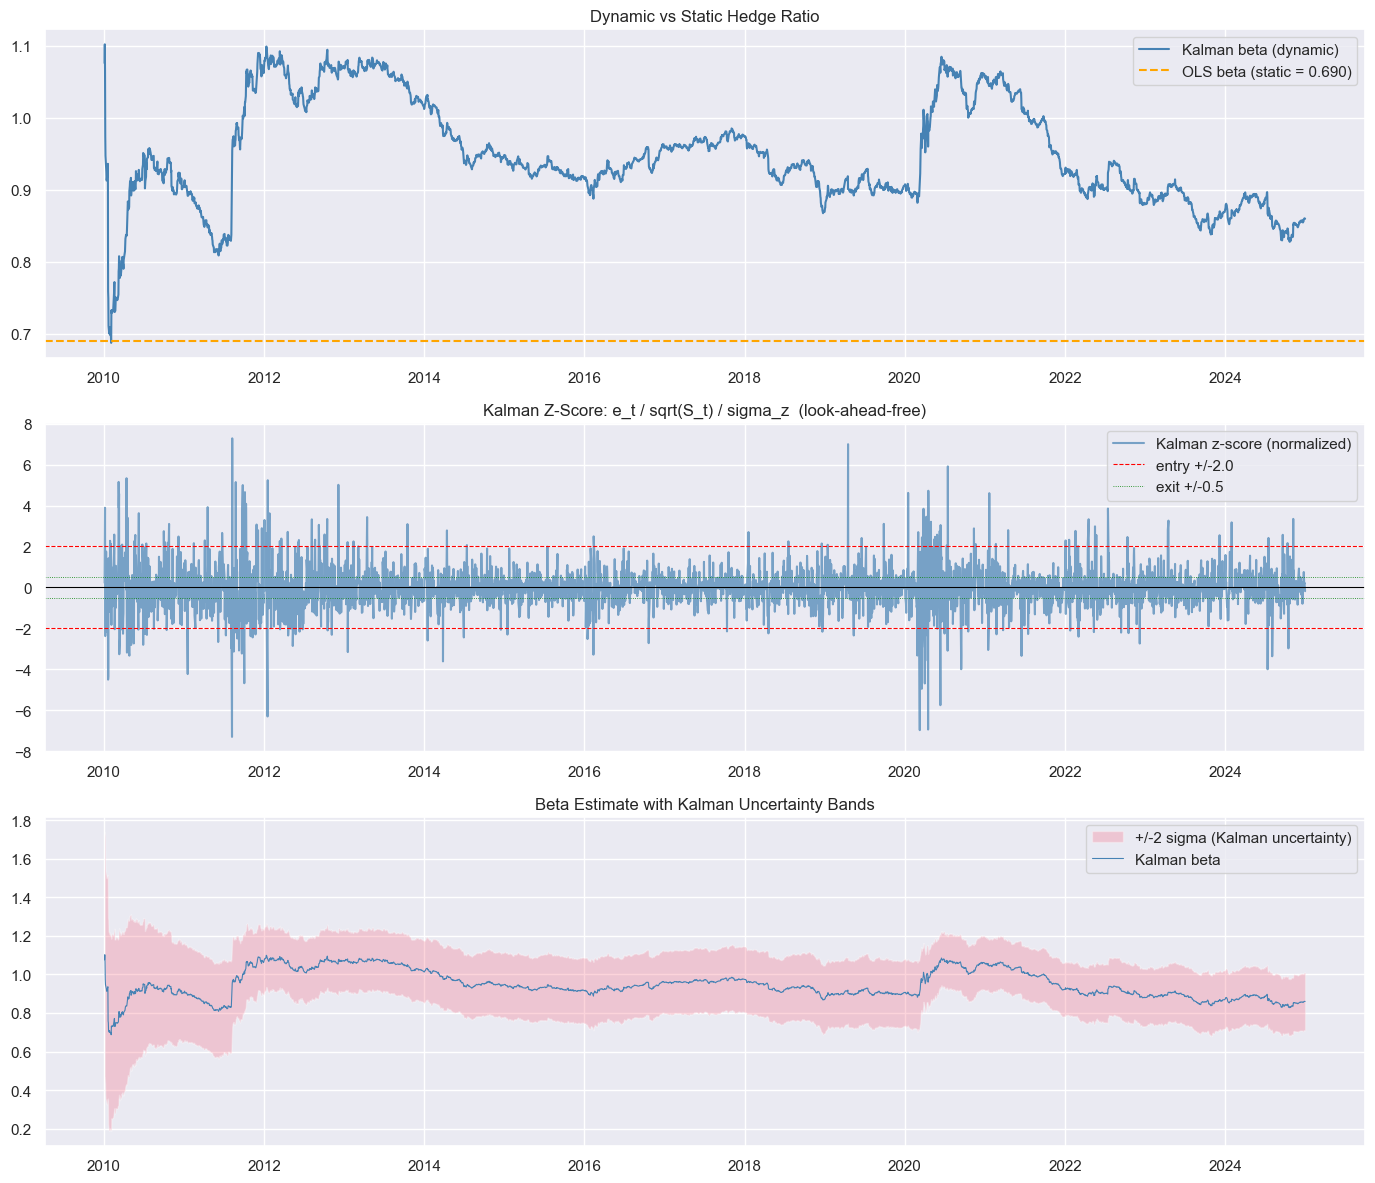

Beta drift over full period: 0.4148
Static OLS beta: 0.6900
sigma_z=0.3528 -> z-score std approx 1.0 in formation (entry at raw |e/sqrt(S)|=0.7056)


In [7]:
if pairs:
    t1, t2 = pairs[0]['pair']
    log_y = log_prices[t1]
    log_x = log_prices[t2]

    R_calib = calibrate_R(log_y, log_x)
    # kalman_spread returns 4 values: betas, alphas, innovations, innov_stds
    betas, alphas, innovations, innov_stds = kalman_spread(log_y, log_x, delta=1e-4, R=R_calib)

    # sigma_z: formation-period z-score std (corrects for P_ss inflation in S_t)
    # Without this, e_t/sqrt(S_t) has std << 1 and entry_z=2.0 is never hit.
    n = len(log_y)
    split = n // 2
    warmup_n = max(50, split // 10)
    form_z = innovations[:split][warmup_n:] / innov_stds[:split][warmup_n:]
    sigma_z = max(0.05, float(np.std(form_z)))
    print(f'Formation z-score std (sigma_z): {sigma_z:.4f}  '
          f'(effective entry threshold in raw units: {2.0 * sigma_z:.4f})')

    # Normalized z-score for full period (for visualization only)
    z_kalman = innovations / innov_stds / sigma_z

    # Static OLS beta for comparison
    _, beta_ols, _ = compute_ols_spread(log_y, log_x)

    fig, axes = plt.subplots(3, 1, figsize=(14, 12))

    # Plot 1: Dynamic vs static beta
    axes[0].plot(log_y.index, betas, label='Kalman beta (dynamic)', color='steelblue')
    axes[0].axhline(beta_ols, color='orange', linewidth=1.5, linestyle='--',
                    label=f'OLS beta (static = {beta_ols:.3f})')
    axes[0].set_title('Dynamic vs Static Hedge Ratio')
    axes[0].legend()
    axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    # Plot 2: Kalman z-score (sigma_z normalized)
    axes[1].plot(log_y.index, z_kalman, alpha=0.7, color='steelblue', label='Kalman z-score (normalized)')
    axes[1].axhline(0, color='black', linewidth=0.8)
    axes[1].axhline(2.0, color='red', linewidth=0.8, linestyle='--', label='entry +/-2.0')
    axes[1].axhline(-2.0, color='red', linewidth=0.8, linestyle='--')
    axes[1].axhline(0.5, color='green', linewidth=0.6, linestyle=':', label='exit +/-0.5')
    axes[1].axhline(-0.5, color='green', linewidth=0.6, linestyle=':')
    axes[1].set_title('Kalman Z-Score: e_t / sqrt(S_t) / sigma_z  (look-ahead-free)')
    axes[1].legend()
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    # Plot 3: Beta uncertainty bands from Kalman P matrix
    kf = KalmanHedgeRatio(delta=1e-4, R=R_calib)
    beta_std = []
    for y_t, x_t in zip(log_y.values, log_x.values):
        kf.update(float(y_t), float(x_t))
        beta_std.append(np.sqrt(kf.P[0, 0]))
    beta_std = np.array(beta_std)

    axes[2].fill_between(log_y.index, betas - 2*beta_std, betas + 2*beta_std,
                         alpha=0.3, label='+/-2 sigma (Kalman uncertainty)')
    axes[2].plot(log_y.index, betas, color='steelblue', linewidth=0.8, label='Kalman beta')
    axes[2].set_title('Beta Estimate with Kalman Uncertainty Bands')
    axes[2].legend()
    axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    plt.tight_layout()
    plt.show()

    drift = betas.max() - betas.min()
    print(f'Beta drift over full period: {drift:.4f}')
    print(f'Static OLS beta: {beta_ols:.4f}')
    print(f'sigma_z={sigma_z:.4f} -> z-score std approx 1.0 in formation (entry at raw |e/sqrt(S)|={2.0*sigma_z:.4f})')

## Summary: All Screened Pairs

In [8]:
if pairs:
    print(f'\nTop pairs summary:')
    for p in pairs[:5]:
        t1, t2 = p['pair']
        spread_ols, _, _ = compute_ols_spread(log_prices[t1], log_prices[t2])
        
        # Formation window OU
        n = len(spread_ols)
        try:
            ou = fit_ou_process(spread_ols.iloc[:n//2])
            hl = f'{ou.half_life:.1f}d'
        except:
            hl = 'N/A'
        
        adf_r = adf_test(spread_ols.iloc[:n//2])
        print(f'  {t1}/{t2:<10}  p={p["p_value"]:.4f}  half-life={hl}  '
              f'ADF-p={adf_r["p_value"]:.4f}  bucket={p["bucket"]}')


Top pairs summary:
  C/BK          p=0.0248  half-life=68.6d  ADF-p=0.0241  bucket=financials
  C/STT         p=0.0603  half-life=84.4d  ADF-p=0.0610  bucket=financials
  EWA/EWC         p=0.0617  half-life=91.3d  ADF-p=0.1297  bucket=commodity_etf
  BAC/C           p=0.0884  half-life=58.1d  ADF-p=0.0020  bucket=financials
  GS/MS          p=0.0957  half-life=38.2d  ADF-p=0.0041  bucket=financials
